## Logistic Regression Evaluation

In [13]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error 
import pickle
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

### Load Dependencies

In [14]:
filename = "logistic_model.sav"
model_C = pickle.load(open(filename, 'rb'))

Accuracy: 0.0000
y_eval sample: <StringArray>
['Diamond', 'Bronze', 'Platinum', 'Immortal', 'Silver']
Length: 5, dtype: str
y_pred sample: <StringArray>
['1', '0']
Length: 2, dtype: str


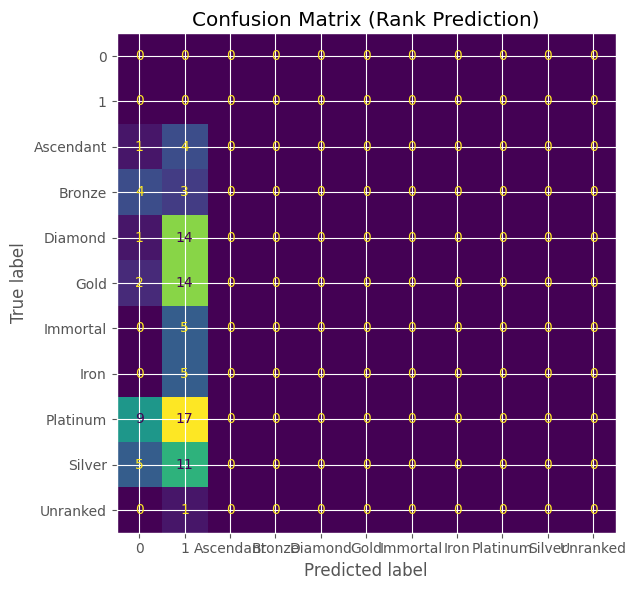

In [18]:
# ...existing code...

# Evaluate
y_pred = model_C.predict(X_eval)

# Normalize label types to avoid int/str conflicts
y_eval = y_eval.astype(str).str.strip()
y_pred = pd.Series(y_pred, index=y_eval.index).astype(str).str.strip()

acc = accuracy_score(y_eval, y_pred)
print(f"Accuracy: {acc:.4f}")

# Optional debug
print("y_eval sample:", y_eval.unique()[:5])
print("y_pred sample:", y_pred.unique()[:5])

fig, ax = plt.subplots(figsize=(7, 6))
labels = sorted(set(y_eval) | set(y_pred))  # safe labels from actual data
cm = confusion_matrix(y_eval, y_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    ax=ax, colorbar=False
)
ax.set_title("Confusion Matrix (Rank Prediction)")
plt.tight_layout()
plt.show()

# ...existing code...